# ECS Scoring & Statistical Analysis

Scores all responses on the two ECS dimensions, computes calibration deltas,
runs statistical tests, and produces visualizations.

**Input:** `data/llm_responses.csv`  
**Outputs:** `data/ecs_scores.csv`, `data/tone_fit_scores.csv`, `figures/delta_kde.png`

Model detection is automatic — re-run after appending `claude_response` to include Claude.

In [1]:
import os, re, csv, time
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv("../.env")
client = OpenAI(api_key=os.environ["OPEN_AI_API_KEY"])
print("Ready")

Ready


In [2]:
df = pd.read_csv("./data/llm_responses.csv", engine="python")

# Detect which model response columns are present — loop variable for all downstream cells
MODELS = [c.replace("_response", "") for c in df.columns if c.endswith("_response")]

print(f"Loaded {len(df)} rows")
print(f"Active models: {MODELS}")
df[["pair_id", "domain", "fis_bin", "customer_text"]].head()

Loaded 600 rows
Active models: ['gpt4o', 'gemini']


,pair_id,domain,fis_bin,customer_text
0,427468,airline,low,@AmericanAir Refund issue - waiting 9/13/17. ...
1,2561739,airline,low,Such fun: sunset from 400+ft up! (@ British Ai...
2,669604,airline,low,"@SouthwestAir And wait, we’re also charging fo..."
3,712118,airline,low,@Delta Thank you CX5 Team. Continue to Inspire...
4,266956,airline,low,Hey @Delta - can you help me with a same day c...


In [3]:
APOLOGY_RE = re.compile(
    r"\b(sorry|apologize|apologise[sd]?|apologi[sz]e[sd]?|apologies|regret|unfortunately|my bad|pardon)\b",
    re.IGNORECASE,
)

def apology_density(text: str) -> float:
    words = str(text).split()
    if not words:
        return 0.0
    count = len(APOLOGY_RE.findall(str(text)))
    # sqrt transform: first apology word carries most weight, additional ones add less
    # e.g. 1 apology / 30 words: raw=0.033 → sqrt=0.182
    return (count / len(words)) ** 0.5

all_cols = ["agent_text"] + [f"{m}_response" for m in MODELS]
for col in all_cols:
    df[f"ad_raw_{col}"] = df[col].apply(apology_density)

# Normalize by global max across human + all active models
ad_max = max(df[f"ad_raw_{c}"].max() for c in all_cols) or 1.0
for col in all_cols:
    df[f"ad_{col}"] = df[f"ad_raw_{col}"] / ad_max

print("Apology density computed and normalized (sqrt transform)")
df[[f"ad_{c}" for c in all_cols]].describe()

Apology density computed and normalized (sqrt transform)


,ad_agent_text,ad_gpt4o_response,ad_gemini_response
count,600.000000,600.000000,600.000000
mean,0.121746,0.241808,0.228974
std,0.209400,0.156757,0.157132
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.319801,0.312772
75%,0.353553,0.348743,0.344124
max,1.000000,0.530330,0.486664


In [4]:
JUDGE_RUBRIC = """\
You are evaluating a customer support response for TONE-FRUSTRATION FIT: \
does the tone of the response appropriately match the emotional register of the complaint?

Score using this 3-point scale:

1 = MISMATCHED
   The response tone is clearly wrong for the situation.
   Examples:
   - Complaint: "@116072 worst customer service I ever received , even tho I love ur product. #disappointed"
     Response:  "@440018 Hello Sue, I would be more than happy to assist you. Please send me a DM. -Katie"
     Why: Customer uses strong words, but agent sounds indifferent and does not seem to want more context about the issue.
   - Complaint: "@SouthwestAir paid for early boarding today while traveling with wife &amp; infant only to be moved to back of plane by crew last minute thanks!"
     Response:  "@709064 Hi, Matt. Did they move you because of a weight and balance concern? ^LJ"
     Why: No compassion words provided to let customers know company cares about them. Plus the overweight question is too private to be asked publicly.

2 = PARTIALLY MATCHED
   The response acknowledges the issue but the tone is noticeably off — either too warm, too cold, or too generic.
   Examples:
   - Complaint: "The one app I DIDNT update after the new iOS was Twitter and it's the only one that opens/doesn't crash. @AppleSupport  FIX IT"
     Response:  "@410910 Let's help take a closer look. Does this seem to persist after rebooting the device? Which apps are most in use when you experience these issues? Are all your apps up to date in the App Store?"
     Why: Good on diving straight to the solution, but could be better if talk with more compassion about the issues in the opening.
   - Complaint: "It would be great if @jetblue would let the passengers know why there is an hour delay. Crew just chatting away."
     Response:  "@316974 Sorry to hear about the delay, Chuck. What's your flight number? The reason might have not been relayed to them just yet."
     Why: Customer is not very frustrated, and is complaining about the delay. The agent identifies the wrong issue and over apologizes. But they did provide valid response in the end.

3 = WELL MATCHED
   The tone is appropriately calibrated — warm and urgent when the customer is upset, \
light and helpful when the inquiry is casual.
   Examples:
   - Complaint: "@115913 @TMobileHelp can anyone help me figure out the mystery of the missing iPhone 7+? Returned a phone, now it's missing. #frustrated"
     Response:  "@728649 @115913 Hi! That's certainly not what I want for you at all and would love to get to the bottom of this. DM us https://t.co/3sF8qpf2nx *AlissaFast"
     Why: Matches the customer's frustration when losing their high value properties, because the agent uses strong words like certainly and at all.s
   - Complaint: "@115714  just picked up a new iPhone 8 from y'all!! Can I get a follow back?!"
     Response:  "@323592 Awesome! :) How do you like your new device? We tried hitting that Follow icon on our end, however, we'll need you to hit it for us! -AJS"
     Why: Delightful tone matches comment that express satisfaction.

---

Complaint: {complaint}
Response: {response}

Reply with a single integer (1, 2, or 3) and nothing else.\
"""

def judge_score(complaint: str, response: str, retries: int = 3) -> int:
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": JUDGE_RUBRIC.format(
                    complaint=complaint, response=response
                )}],
                temperature=0,
            )
            return int(resp.choices[0].message.content.strip())
        except Exception:
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)

print("Judge rubric and scoring function defined")

Judge rubric and scoring function defined


In [5]:
TF_OUT = "./data/tone_fit_scores.csv"
CHECKPOINT = 50

# Load or initialise checkpoint file
if os.path.exists(TF_OUT):
    tf_df = pd.read_csv(TF_OUT).set_index("pair_id")
    print(f"Resuming — loaded {len(tf_df)} rows from checkpoint")
else:
    tf_df = pd.DataFrame(index=df["pair_id"])
    tf_df.index.name = "pair_id"

# Ensure a column exists for every target (human + all active models)
score_cols = ["tf_human"] + [f"tf_{m}" for m in MODELS]
for col in score_cols:
    if col not in tf_df.columns:
        tf_df[col] = np.nan

# Score any missing cells — adds new model columns when MODELS grows
for _, row in df.iterrows():
    pid = row["pair_id"]
    if pid not in tf_df.index:
        tf_df.loc[pid] = np.nan

    if pd.isna(tf_df.loc[pid, "tf_human"]):
        tf_df.loc[pid, "tf_human"] = judge_score(row["customer_text"], row["agent_text"])

    for m in MODELS:
        col = f"tf_{m}"
        if pd.isna(tf_df.loc[pid, col]):
            tf_df.loc[pid, col] = judge_score(row["customer_text"], row[f"{m}_response"])

    completed = int(tf_df[score_cols].notna().all(axis=1).sum())
    if completed % CHECKPOINT == 0 and completed > 0:
        tf_df.reset_index().to_csv(TF_OUT, index=False)
        print(f"  checkpoint — {completed} rows fully scored")

tf_df.reset_index().to_csv(TF_OUT, index=False)
print(f"Done — tone-fit scores saved to {TF_OUT}")
tf_df.head()

Resuming — loaded 600 rows from checkpoint
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully scored
  checkpoint — 600 rows fully sc

,tf_human,tf_gpt4o,tf_gemini
pair_id,,,
427468,1.0,3.0,3.0
2561739,3.0,3.0,3.0
669604,2.0,2.0,3.0
712118,3.0,3.0,3.0
266956,3.0,2.0,3.0


In [6]:
tf = pd.read_csv(TF_OUT)
df = df.merge(tf, on="pair_id")
print(df.head())
# FIS-conditional weights: apology density has higher weight at high frustration
w_ad = df["fis_bin"].map({"high": 0.6, "moderate": 0.5, "low": 0.5})
w_tf = 1 - w_ad

# Human ECS baseline — shared reference for all model deltas
df["tf_human_norm"] = df["tf_human"] / 3
df["ecs_human"] = w_ad * df["ad_agent_text"] + w_tf * df["tf_human_norm"]

# ECS, composite delta, and decomposed component deltas per active model
for m in MODELS:
    df[f"tf_{m}_norm"] = df[f"tf_{m}"] / 3
    df[f"ecs_{m}"]      = w_ad * df[f"ad_{m}_response"] + w_tf * df[f"tf_{m}_norm"]
    df[f"delta_{m}"]    = df[f"ecs_{m}"] - df["ecs_human"]
    # Component-level deltas (unweighted) for attribution analysis
    df[f"delta_ad_{m}"] = df[f"ad_{m}_response"] - df["ad_agent_text"]   # apology density gap
    df[f"delta_tf_{m}"] = df[f"tf_{m}_norm"]      - df["tf_human_norm"]  # tone-fit gap

delta_cols = [f"delta_{m}" for m in MODELS]
print(f"ECS computed for models: {MODELS}")
print(df[delta_cols].describe())

df.to_csv("./data/ecs_scores.csv", index=False, quoting=csv.QUOTE_ALL)
print("Saved ./data/ecs_scores.csv")

   pair_id   domain fis_bin  \
0   427468  airline     low   
1  2561739  airline     low   
2   669604  airline     low   
3   712118  airline     low   
4   266956  airline     low   

                                       customer_text  \
0  @AmericanAir Refund issue - waiting 9/13/17.  ...   
1  Such fun: sunset from 400+ft up! (@ British Ai...   
2  @SouthwestAir And wait, we’re also charging fo...   
3  @Delta Thank you CX5 Team. Continue to Inspire...   
4  Hey @Delta - can you help me with a same day c...   

                                          agent_text  \
0  @216667 The team is working though refund requ...   
1  @170611 The best location to contemplate sunse...   
2  @279703 We're truly sorry for your continued f...   
3  @143983 Thanks! It is our pleasure to take car...   
4  @179627 Hi, David! I'd be happy to further ass...   

                                      gpt4o_response  \
0  I'm sorry to hear about the ongoing issue with...   
1  That sounds like an amaz

## Statistical Analysis

**Test 1** — One-sample t-test per model: is the mean calibration delta Δ significantly different from zero?  
**Test 2** — Two-way ANOVA (model × domain): does miscalibration vary by industry context?

In [7]:
print("=== Test 1: One-sample t-test (Δ vs 0) ===\n")
for m in MODELS:
    deltas = df[f"delta_{m}"].dropna()
    t_stat, p_val = stats.ttest_1samp(deltas, 0)
    cohens_d = deltas.mean() / deltas.std(ddof=1)
    ci_lo, ci_hi = stats.t.interval(0.95, df=len(deltas) - 1,
                                    loc=deltas.mean(), scale=stats.sem(deltas))
    direction = "over-empathizes" if deltas.mean() > 0 else "under-empathizes"
    sig = "**" if p_val < 0.05 else "ns"

    mean_ad = df[f"delta_ad_{m}"].mean()
    mean_tf = df[f"delta_tf_{m}"].mean()
    # Determine which component is the primary driver
    if abs(mean_ad) >= abs(mean_tf):
        driver = f"apology density (Δ_ad={mean_ad:+.4f})"
    else:
        driver = f"tone-fit (Δ_tf={mean_tf:+.4f})"

    print(f"{m}:")
    print(f"  composite Δ = {deltas.mean():+.4f}  ({direction})  {sig}")
    print(f"  95% CI = [{ci_lo:.4f}, {ci_hi:.4f}]  |  t = {t_stat:.3f},  p = {p_val:.4f}  |  Cohen's d = {cohens_d:.3f}")
    print(f"  decomposed:  Δ_apology_density = {mean_ad:+.4f}  |  Δ_tone_fit = {mean_tf:+.4f}")
    print(f"  primary driver: {driver}")
    print()

# Attribution summary table
print("=== Attribution Summary ===")
summary = []
for m in MODELS:
    summary.append({
        "model":          m,
        "composite Δ":    round(df[f"delta_{m}"].mean(), 4),
        "Δ apology_density": round(df[f"delta_ad_{m}"].mean(), 4),
        "Δ tone_fit":     round(df[f"delta_tf_{m}"].mean(), 4),
        "driver":         "apology_density" if abs(df[f"delta_ad_{m}"].mean()) >= abs(df[f"delta_tf_{m}"].mean()) else "tone_fit",
    })
print(pd.DataFrame(summary).to_string(index=False))

=== Test 1: One-sample t-test (Δ vs 0) ===

gpt4o:
  composite Δ = +0.0973  (over-empathizes)  **
  95% CI = [0.0841, 0.1104]  |  t = 14.502,  p = 0.0000  |  Cohen's d = 0.592
  decomposed:  Δ_apology_density = +0.1201  |  Δ_tone_fit = +0.0694
  primary driver: apology density (Δ_ad=+0.1201)

gemini:
  composite Δ = +0.1736  (over-empathizes)  **
  95% CI = [0.1596, 0.1876]  |  t = 24.354,  p = 0.0000  |  Cohen's d = 0.994
  decomposed:  Δ_apology_density = +0.1072  |  Δ_tone_fit = +0.2494
  primary driver: tone-fit (Δ_tf=+0.2494)

=== Attribution Summary ===
 model  composite Δ  Δ apology_density  Δ tone_fit          driver
 gpt4o       0.0973             0.1201      0.0694 apology_density
gemini       0.1736             0.1072      0.2494        tone_fit


In [ ]:
print("=== Test 2: Two-way ANOVA (model × domain) ===\n")

# Melt to long format — one row per (pair_id, model)
long = pd.melt(
    df[["pair_id", "domain", "fis_bin"] + [f"delta_{m}" for m in MODELS]],
    id_vars=["pair_id", "domain", "fis_bin"],
    value_vars=[f"delta_{m}" for m in MODELS],
    var_name="model",
    value_name="delta",
)
long["model"] = long["model"].str.replace("delta_", "", regex=False)

anova_fit = ols("delta ~ C(model) + C(domain) + C(model):C(domain)", data=long).fit()
anova_table = sm.stats.anova_lm(anova_fit, typ=2)
print(anova_table)

=== Test 2: Two-way ANOVA (model × domain) ===

                       sum_sq      df           F        PR(>F)
C(model)             1.748185     1.0   66.775425  7.678852e-16
C(domain)            3.093601     1.0  118.166307  2.587118e-26
C(model):C(domain)   0.028125     1.0    1.074295  3.001868e-01
Residual            31.311357  1196.0         NaN           NaN

--- Tukey HSD post-hoc (model × domain cells) ---
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
      group1            group2      meandiff p-adj  lower   upper  reject
-------------------------------------------------------------------------
   gemini_airline gemini_technology   0.1112   0.0  0.0772  0.1452   True
   gemini_airline     gpt4o_airline  -0.0667   0.0 -0.1006 -0.0327   True
   gemini_airline  gpt4o_technology   0.0252 0.225 -0.0088  0.0592  False
gemini_technology     gpt4o_airline  -0.1779   0.0 -0.2119 -0.1439   True
gemini_technology  gpt4o_technology   -0.086   0.0   -0.12  -0.

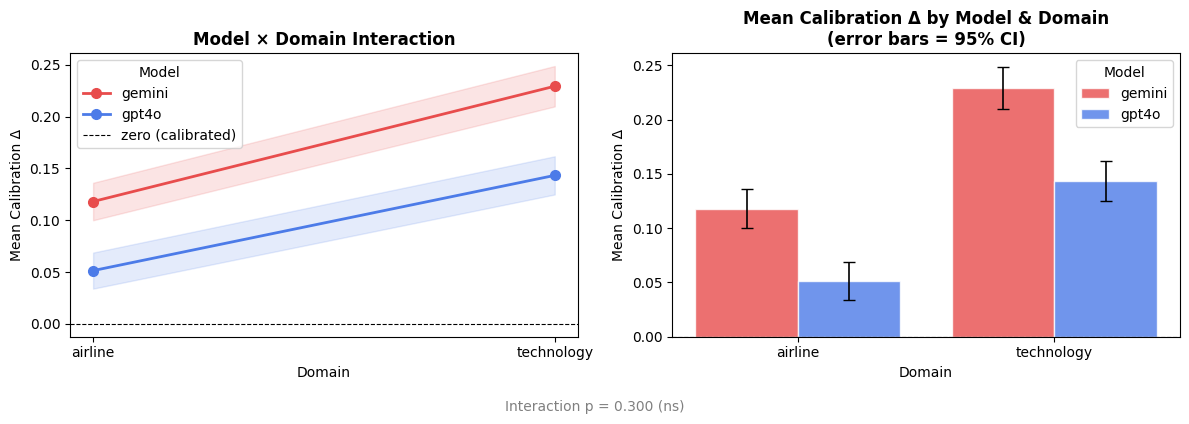

Saved ./figures/anova_interaction.png


In [9]:
MODEL_COLORS = {"gpt4o": "#4c7be8", "gemini": "#e84c4c", "claude": "#4ce87a"}

# Compute cell means and 95% CI
cell_stats = (
    long.groupby(["model", "domain"])["delta"]
    .agg(mean="mean", se=stats.sem)
    .reset_index()
)
cell_stats["ci95"] = cell_stats["se"] * stats.t.ppf(0.975, df=598)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Panel 1: Interaction plot ---
ax = axes[0]
for model, grp in cell_stats.groupby("model"):
    color = MODEL_COLORS.get(model, "gray")
    ax.plot(grp["domain"], grp["mean"], marker="o", label=model,
            color=color, linewidth=2, markersize=7)
    ax.fill_between(
        grp["domain"],
        grp["mean"] - grp["ci95"],
        grp["mean"] + grp["ci95"],
        alpha=0.15, color=color,
    )
ax.axhline(0, color="black", linestyle="--", linewidth=0.8, label="zero (calibrated)")
ax.set_title("Model × Domain Interaction", fontweight="bold")
ax.set_xlabel("Domain")
ax.set_ylabel("Mean Calibration Δ")
ax.legend(title="Model")
ax.set_xticks(["airline", "technology"])

# --- Panel 2: Grouped bar chart with 95% CI ---
ax = axes[1]
domains = cell_stats["domain"].unique()
models  = cell_stats["model"].unique()
x = np.arange(len(domains))
bar_w = 0.8 / len(models)

for i, model in enumerate(models):
    grp = cell_stats[cell_stats["model"] == model].set_index("domain").reindex(domains)
    offset = (i - (len(models) - 1) / 2) * bar_w
    color = MODEL_COLORS.get(model, "gray")
    ax.bar(x + offset, grp["mean"], width=bar_w, label=model,
           color=color, alpha=0.8, edgecolor="white")
    ax.errorbar(x + offset, grp["mean"], yerr=grp["ci95"],
                fmt="none", color="black", capsize=4, linewidth=1.2)

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(domains)
ax.set_title("Mean Calibration Δ by Model & Domain\n(error bars = 95% CI)", fontweight="bold")
ax.set_xlabel("Domain")
ax.set_ylabel("Mean Calibration Δ")
ax.legend(title="Model")

# Interaction p-value annotation
interaction_p = anova_table.loc["C(model):C(domain)", "PR(>F)"]
sig_label = f"Interaction p = {interaction_p:.3f}" + (" *" if interaction_p < 0.05 else " (ns)")
fig.text(0.5, -0.04, sig_label, ha="center", fontsize=10, color="gray")

plt.tight_layout()
os.makedirs("./figures", exist_ok=True)
plt.savefig("./figures/anova_interaction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ./figures/anova_interaction.png")

## Visualisation

KDE plots of calibration delta (Δ) distributions, faceted by model and coloured by FIS bin.

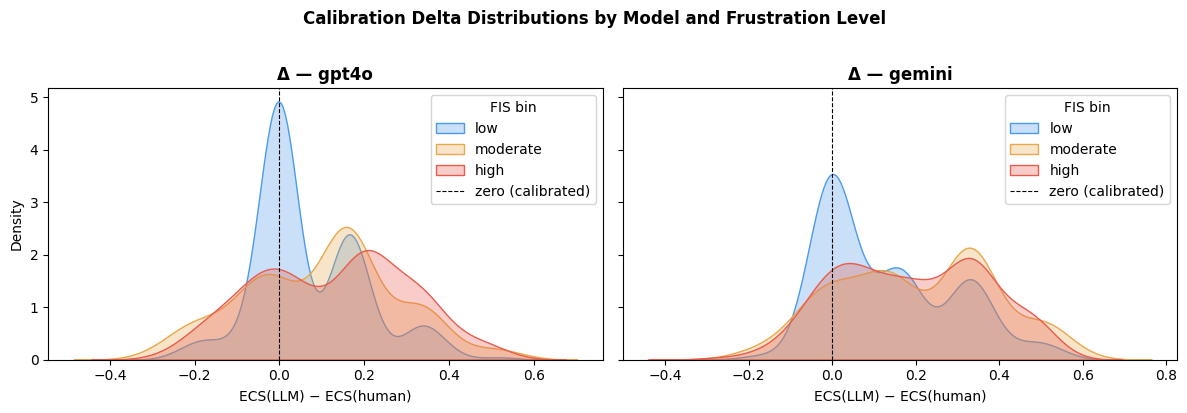

Saved ./figures/delta_kde.png


In [10]:
n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4), sharey=True)
if n_models == 1:
    axes = [axes]

FIS_ORDER = ["low", "moderate", "high"]
PALETTE = {"low": "#4c9be8", "moderate": "#e8a84c", "high": "#e85c4c"}

for ax, m in zip(axes, MODELS):
    for fis_bin in FIS_ORDER:
        grp = df[df["fis_bin"] == fis_bin][f"delta_{m}"].dropna()
        if len(grp) > 1:
            sns.kdeplot(grp, ax=ax, label=fis_bin,
                        color=PALETTE[fis_bin], fill=True, alpha=0.3)
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8, label="zero (calibrated)")
    ax.set_title(f"Δ — {m}", fontweight="bold")
    ax.set_xlabel("ECS(LLM) − ECS(human)")
    ax.legend(title="FIS bin")

axes[0].set_ylabel("Density")
fig.suptitle("Calibration Delta Distributions by Model and Frustration Level",
             fontweight="bold", y=1.02)
plt.tight_layout()

os.makedirs("./figures", exist_ok=True)
plt.savefig("./figures/delta_kde.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ./figures/delta_kde.png")